## Introduction
In this notebook, we train a network on the pincell moment dataset that will share certain equivariance properties incurred by the symmetry of the domain under transformations of the Diheadral group of order 8 ($D_4$). This will hopefully decrease the number of parameters required to train the model (as compared with a FCN), and encorporate some problem specific inductive bias that will aid generalization.

## Rotational Equivariance Implies Permutation Invariance of Surfaces
In the title

## Reflection Equivariance Implies 180 Degree Rotation Equivariance (in the spatial and angular indices) of Input Coefficient Array
Also in the title

## Network Architecture
To encode the first equivariance, we use a Graph Neural Network Architecture (GNN), and to encode the second equivariance, we use a 180 degree rotation equivariant convolutional neural network with weight tying (i.e. the filters are constrained to be invariant under 180 degree rotations).

### CNN Architecture
CNN architecture inspired by spatial characteristics of the Bernstein polynomials and overlap of basis functions -> local correlation in coefficient array.

Now, since the domain is not necessarily translation equivariant (though some small amount of translation equivariance may be observed in practice), we need some way to break this equivariance, and we do so by explicitly introducing some position encoding as an additional chanel in the input (3D) tensor. Importantly, to preserve the 180 degree rotation equivariance, we must ensure that this position encoding is invariant under 180 degree rotations. There are several different types of such positional encodings, so we decided to use 7 of them to ensure expressivity of translation equivariance violation.

#### Encoder Architecture
We do this position encoding then feed the data into an upsampling equivariant CNN (transpose convolution) to create a higher resolution "image" also in a higher dimension in channel space to provide an expressive embedding. This was thought to be necessary because, to obtain adequate statistics with a computationally manageable number of neutron histories in pincell calculations, we needed to keep the expansion order small, so the coefficient arrays are only of dimension $7\times 5 \times 8$, which may not be expressive enough to capture the complexity of the neutron transport process. We also encode the surface weights as an additional, uniform, channel here.

#### Decoder Architectures
We have technically have three encoders, all of which take the 4 surface embeddings produced at the final layer of the graph neural network as input. First, we apply a common equivariant CNN to each embedding to generate the outgoing fluxes, this also collapses the image size back to the original by downsampling with a stride length of 2. Then, at the final layer of this network, we have one layer that generates the final image (via a convolution layer), and one that generates the single scalar weight for the image (surface) by an adaptive average pooling and a sigmoid activation to ensure the weight is ∈[0,1].

Now, since, unfortunately, the pin power coefficients do not obey the same, simple, equivariance as do the surface flux expansion coefficients, we simply concatenate (channel wise) the 4 surface embeddings and pass it through a standard CNN to produce the output pin power coefficients.

Finally, since we require keff to be _invariant_ (not equivariant) under 180 degree rotations and under rotations/reflections (permutation of surfaces), we require keff to take a sum of the surface embeddings as input. We then simply map this value to a scalar by a FCNN, and apply a softplus to ensure strict positivity of keff predictions.

### GNN Architecture
The GNN uses the equivariant CNN in both message passing and updating. Not much else to say about this

## Read in the Dataset

In [16]:
import zarr

dataset_path = '../dataset_generation/full_dataset/dataset.zarr'

# Open the dataset in read mode
root = zarr.open_group(dataset_path, mode='r')

# Access the arrays
X_flux = root["X_flux_coeffs"]
X_wts  = root["X_weights"]
Y_flux = root["Y_flux_coeffs"]
Y_pow  = root["Y_power_coeffs"]
Y_keff  = root["Y_keff"]
Y_wts = root["Y_weights"]

## Define the Equivariant CNN Architecture

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def rotate180_spatial(kernel_3d):
    # kernel_3d shape: (C_out, C_in, kD, kH, kW)
    return torch.rot90(kernel_3d, k=2, dims=[-1, -2])  # rotate over (H, W)

# Reusable 3D symmetric convolution layer
class SymmetricConv3D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3,3), stride=1, padding=1, bias=True, transpose=False):
        super().__init__()
        self.transpose = transpose
        if transpose:
            # Transposed expects (in_channels, out_channels, ...)
            self.weight_raw = nn.Parameter(torch.randn(in_channels, out_channels, *kernel_size))
        else:
            self.weight_raw = nn.Parameter(torch.randn(out_channels, in_channels, *kernel_size))

        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride = stride
        self.padding = padding

    def forward(self, x):
        # Permute (B, C, H, W, D) → (B, C, D, H, W)
        x = x.permute(0, 1, 4, 2, 3)
        w = 0.5 * (self.weight_raw + rotate180_spatial(self.weight_raw))

        if self.transpose:
            out = F.conv_transpose3d(x, w, bias=self.bias, stride=self.stride, padding=self.padding)
        else:
            out = F.conv3d(x, w, bias=self.bias, stride=self.stride, padding=self.padding)

        return out.permute(0, 1, 3, 4, 2)  # (B, C, H, W, D)

class SymmetricConvNet3D(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()
        assert num_layers >= 1, "Must have at least one layer"

        layers = []

        if num_layers == 1:
            layers.append(SymmetricConv3D(in_channels, out_channels, stride=1, transpose=False, padding=1))
        else:
            layers.append(SymmetricConv3D(in_channels, hidden_channels, stride=1, transpose=False, padding=1))
            layers.append(nn.ReLU())
            for _ in range(num_layers - 2):
                layers.append(SymmetricConv3D(hidden_channels, hidden_channels, stride=1, transpose=False, padding=1))
                layers.append(nn.ReLU())
            layers.append(SymmetricConv3D(hidden_channels, out_channels, stride=1, transpose=False, padding=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() == 6:  # [B, N, C, H, W, D]
            B, N, C, H, W, D = x.shape
            x = x.reshape(B * N, C, H, W, D)  # → [B*N, C, H, W, D]
            out = self.net(x)
            out = out.reshape(B, N, *out.shape[1:])  # → [B, N, C, H, W, D]
            return out
        elif x.dim() == 5:  # [B, C, H, W, D] — single node input
            return self.net(x)
        else:
            raise ValueError(f"Unexpected input shape {x.shape}")

## Define the Encoder

In [18]:
def make_3d_position_encodings(H, W, D, batch_size):
    import numpy as np

    # Coordinate grids
    i = np.arange(H).reshape(H, 1, 1).astype(np.float32)
    j = np.arange(W).reshape(1, W, 1).astype(np.float32)
    k = np.arange(D).reshape(1, 1, D).astype(np.float32)

    # Centering
    i0 = (H - 1) / 2
    j0 = (W - 1) / 2
    k0 = (D - 1) / 2

    I = i - i0
    J = j - j0
    K = k - k0

    I_full = I + np.zeros((H, W, D), dtype=np.float32)
    J_full = J + np.zeros((H, W, D), dtype=np.float32)
    K_full = K + np.zeros((H, W, D), dtype=np.float32)

    # Normalizations
    H2, W2, D2 = H**2, W**2, D**2
    HW, HD, WD, HWD = H * W, H * D, W * D, H * W * D

    # Invariant under 180° spatial (I,J) rotation:
    r2_spatial = (I_full**2 + J_full**2) / (H2 + W2)                # radial in-plane
    r2_full = (I_full**2 + J_full**2 + K_full**2) / (H2 + W2 + D2)  # full 3D radius squared
    IJ = (I_full * J_full) / HW                                     # spatial interaction
    IK2 = (I_full**2 * K_full) / (H2 * D)                           # spatial^2 × depth
    JK2 = (J_full**2 * K_full) / (W2 * D)                           # spatial^2 × depth
    IJK = (I_full * J_full * K_full) / HWD                          # full 3-way interaction

    pos_channels = [r2_spatial, r2_full, IJ, IK2, JK2, IJK]

    pos_stack = np.stack(pos_channels, axis=0).astype(np.float32)  # (C, H, W, D)
    pos_stack_batched = np.broadcast_to(
        pos_stack[None, :, :, :, :], (batch_size, len(pos_channels), H, W, D)
    )

    return pos_stack_batched


class SpatialRotEquivariantUpsample3D(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()
        assert num_layers >= 1, "Must have at least one layer"

        layers = []

        if num_layers == 1:
            # Direct upsample from in → out
            layers.append(SymmetricConv3D(in_channels, out_channels, stride=2, transpose=True, padding=1))
        else:
            # First layer: upsample
            layers.append(SymmetricConv3D(in_channels, hidden_channels, stride=2, transpose=True, padding=1))
            layers.append(nn.ReLU())
            # Middle layers (if any): normal conv
            for _ in range(num_layers - 2):
                layers.append(SymmetricConv3D(hidden_channels, hidden_channels, stride=1, transpose=True, padding=1))
                layers.append(nn.ReLU())
            # Final layer: output channels, no activation
            layers.append(SymmetricConv3D(hidden_channels, out_channels, stride=1, transpose=True, padding=1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Define the Decoders

In [19]:
class DecodeCoefficients(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2):
        super().__init__()
        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        current_in = in_channels

        for i in range(num_layers):
            is_first = (i == 0)
            is_last = (i == num_layers - 1)

            out_channels = out_channels if is_last else hidden_channels
            stride = 2 if is_first else 1

            layers.append(SymmetricConv3D(in_channels=current_in, out_channels=out_channels, stride=stride, transpose=False, padding=1))

            current_in = out_channels

            if not is_last:
                layers.append(nn.ReLU())

        self.feature_extractor = nn.Sequential(*layers)
        self.image_head = SymmetricConv3D(in_channels=out_channels, out_channels=1, stride=1, transpose=False, padding=1)
        self.scalar_head = nn.Sequential(nn.AdaptiveAvgPool3d((1, 1, 1)), nn.Flatten(), nn.Linear(out_channels, 1), nn.Sigmoid())

    def forward(self, x):
        embedding = self.feature_extractor(x)
        image_out = self.image_head(embedding)
        pooled = embedding.permute(0, 1, 4, 2, 3)
        scalar_out = self.scalar_head(pooled).squeeze(-1)
        
        return image_out, scalar_out

class DecodePinPower(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_shape=(15,8)):
        super().__init__()
        self.out_shape = out_shape

        # Combine 4 tensors along channel axis: (B, 4*C, H, W, D)
        self.net = nn.Sequential(
            nn.Conv3d(in_channels=4 * in_channels, out_channels=hidden_channels, kernel_size=(3,3,3), padding=1),
            nn.ReLU(),
            nn.Conv3d(in_channels=hidden_channels, out_channels=hidden_channels, kernel_size=(3,3,3), padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool3d((1, out_shape[0], out_shape[1]))  # Output shape: (B, C, 1, 15, 8)
        )

        input_dim = hidden_channels * out_shape[0] * out_shape[1]
        output_dim = out_shape[0] * out_shape[1]
        self.final_proj = nn.Sequential(
            nn.Flatten(start_dim=1),           # (B, hidden_channels*1*15*8)
            nn.Linear(input_dim, output_dim),  # map to 15*8
        )

    def forward(self, x_list):
        # x_list: list of 4 tensors, each (B, C, H, W, D)
        x = torch.cat(x_list, dim=1)  # (B, 4*C, H, W, D)
        out = self.net(x)             # (B, C, 1, 15, 8)
        out = self.final_proj(out).squeeze(1)  # (B, 15*8)
        return out.view(-1, *self.out_shape)   # (B, 15, 8)
    
class DecodeKeff(nn.Module):
    def __init__(self, in_channels=12, hidden_dim=8):
        super().__init__()
        # 1) Shrink 3D feature map (B, 12, H, W, D) to (B, 12, 1, 1, 1)
        self.global_pool = nn.AdaptiveAvgPool3d(1)  

        # 2) Map from 12 → hidden_dim → 1
        self.fc = nn.Sequential(
            nn.Flatten(start_dim=1),         # (B, 12, 1, 1, 1) → (B, 12)
            nn.Linear(in_channels, hidden_dim),  
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),         # single scalar 
            nn.Softplus()
        )

    def forward(self, x_list):
        """
        x_list: a list of length N (say 4 surfaces),
                each element is shape (B, 12, H, W, D).
        """
        # 1) Stack along a new dimension => (N, B, 12, H, W, D)
        #    sum along that dim => (B, 12, H, W, D)
        x = torch.stack(x_list, dim=0).sum(dim=0)

        # 2) Global 3D average pooling => (B, 12, 1, 1, 1)
        x = self.global_pool(x)

        # 3) Flatten & linear => (B, 1)
        out = self.fc(x)
        return out


## Define GNN Architecture

In [20]:
class EquivariantGNNLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_cnn_layers):
        super().__init__()
        self.message_fn = SymmetricConvNet3D(in_channels, hidden_channels, out_channels, num_cnn_layers)
        self.update_fn = SymmetricConvNet3D(in_channels + out_channels, hidden_channels, out_channels, num_cnn_layers)

    def forward(self, x):
        # x: [B, N, C, H, W, D]
        B, N, C, H, W, D = x.shape
        messages = []

        for i in range(N):
            m = 0
            for j in range(N):
                # Apply CNN to x[:, j] (shape [B, C, H, W, D])
                message = self.message_fn(x[:, j])
                m = m + message  # Sum over neighbors
            messages.append(m)

        messages = torch.stack(messages, dim=1)  # [B, N, C', H, W, D]
        updated_input = torch.cat([x, messages], dim=2)  # Concat along channels
        return self.update_fn(updated_input)


class EquivariantGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, num_cnn_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            EquivariantGNNLayer(
                in_channels=out_channels if i > 0 else in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_cnn_layers=num_cnn_layers
            ) for i in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

## Now Test a Forward Pass

In [28]:
import numpy as np

model = SpatialRotEquivariantUpsample3D(in_channels=8, hidden_channels=8, out_channels=12, num_layers=3)

max_samples = 50

out1 = []
out2 = []

for surface in range(4):
    input = np.moveaxis(Y_flux[:max_samples, surface, :, :, :, :], -1, 1)

    # input shape: (B, C, H, W)embed_dim
    B, C, H, W, D = input.shape


    # Generate symmetric positional channel
    pos_encodings = make_3d_position_encodings(H, W, D, B)

    # Which output channel to look at to test rotation equivariance
    out_channel_test = 0

    # Append weight channels to input
    surface_wts = X_wts[:max_samples, surface]
    surface_wts = np.tile(surface_wts[:, None, None, None, None], (1, H, W, D))
    input = np.concatenate((input, surface_wts), axis=1)


    # Test the forward pass
    input1 = torch.tensor(np.concatenate((input, pos_encodings), axis=1), dtype=torch.float32)
    out1.append(model.forward(input1))

    # Test the forward pass with rotated input (should get rotated output)
    input2 = np.rot90(input, 2, axes=(2, 3))
    input2 = np.concatenate((input2, pos_encodings), axis=1)
    input2 = torch.tensor(input2.copy(), dtype=torch.float32)
    out2.append(model.forward(input2))

out1 = torch.stack(out1, dim=1)
out2 = torch.stack(out2, dim=1)

gnn = EquivariantGNN(in_channels=12, hidden_channels=12, out_channels=12, num_layers=3, num_cnn_layers=3)
out1 = gnn.forward(out1)[0, 0, 0]
out2 = gnn.forward(out2)[0, 0, 0]

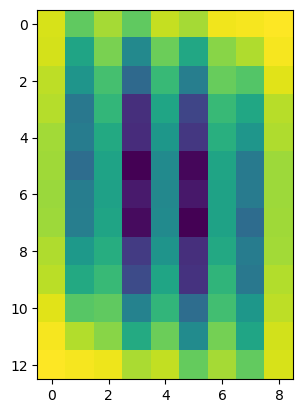

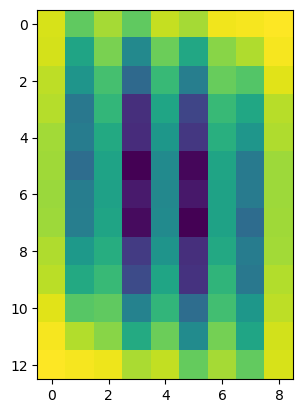

In [29]:
import matplotlib.pyplot as plt

energy_idx = 2

# Rotated output
plt.imshow(np.rot90(out1.detach().numpy()[:, :, energy_idx], 2))
plt.show()
# Output of rotated input
plt.imshow(out2.detach().numpy()[:, :, energy_idx])
plt.show()